# PRCP-1020-HousePricePred

# Task 1:- Prepare a complete data analysis report on the given data

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## Load DataSet

In [2]:
df=pd.read_csv("data.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print(df.shape)

(1460, 81)


## Simple checks

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
df.describe(include=object)

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


# check null values

In [7]:
pd.set_option('display.max_rows',None)
df.isnull().sum().sort_values()

Id                  0
TotalBsmtSF         0
Heating             0
SaleCondition       0
CentralAir          0
1stFlrSF            0
2ndFlrSF            0
LowQualFinSF        0
GrLivArea           0
BsmtFullBath        0
BsmtHalfBath        0
FullBath            0
HalfBath            0
BedroomAbvGr        0
KitchenAbvGr        0
KitchenQual         0
TotRmsAbvGrd        0
Functional          0
SaleType            0
YrSold              0
MoSold              0
MiscVal             0
PoolArea            0
ScreenPorch         0
BsmtUnfSF           0
3SsnPorch           0
OpenPorchSF         0
WoodDeckSF          0
PavedDrive          0
GarageArea          0
GarageCars          0
Fireplaces          0
EnclosedPorch       0
BsmtFinSF2          0
HeatingQC           0
SalePrice           0
Utilities           0
LandContour         0
Neighborhood        0
Condition1          0
LotShape            0
Street              0
LotArea             0
BsmtFinSF1          0
Condition2          0
BldgType  

In [8]:
df=df.drop('Id',axis=1)

In [9]:
df.isnull().sum().to_frame('Missing_Values') \
.assign(DataType=df.dtypes) \
.sort_values(by='Missing_Values', ascending=False)\
.head(20)

,Missing_Values,DataType
PoolQC,1453,object
MiscFeature,1406,object
Alley,1369,object
Fence,1179,object
MasVnrType,872,object
FireplaceQu,690,object
LotFrontage,259,float64
GarageYrBlt,81,float64
GarageCond,81,object
GarageType,81,object


## log Transformation on target Column

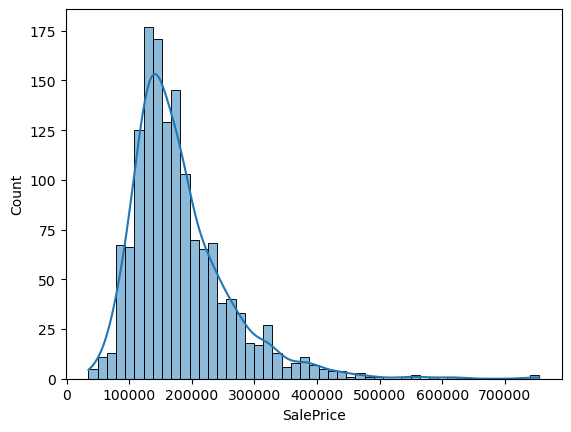

np.float64(1.8828757597682129)

In [10]:
sns.histplot(df['SalePrice'], kde=True)
plt.show()

df['SalePrice'].skew()


In [11]:
df['SalePrice_log'] = np.log1p(df['SalePrice'])

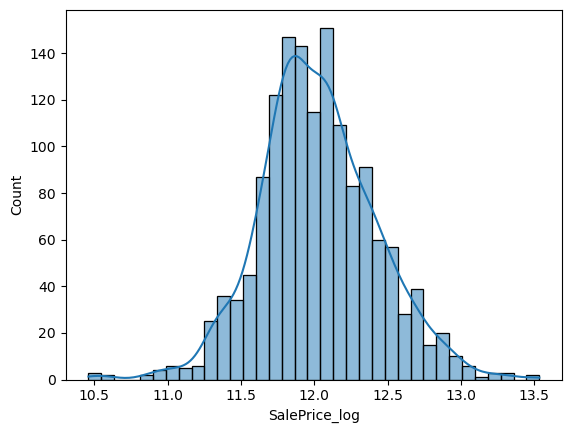

np.float64(0.12134661989685333)

In [12]:
sns.histplot(df['SalePrice_log'], kde=True)
plt.show()

df['SalePrice_log'].skew()

In [13]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

# EDA ( Exploratory Data Analysis).

In [14]:
#seprating num cols and Cat cols
num_cols= df.drop(['SalePrice','SalePrice_log'],axis=1)\
.select_dtypes(include=['int64','float64']).columns
cat_cols= df.select_dtypes(include=['object']).columns

# NUMERICAL Cols EDA

In [15]:
num_cols

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')

In [16]:
df[num_cols].describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


In [17]:
df[cat_cols].describe(include=object)

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


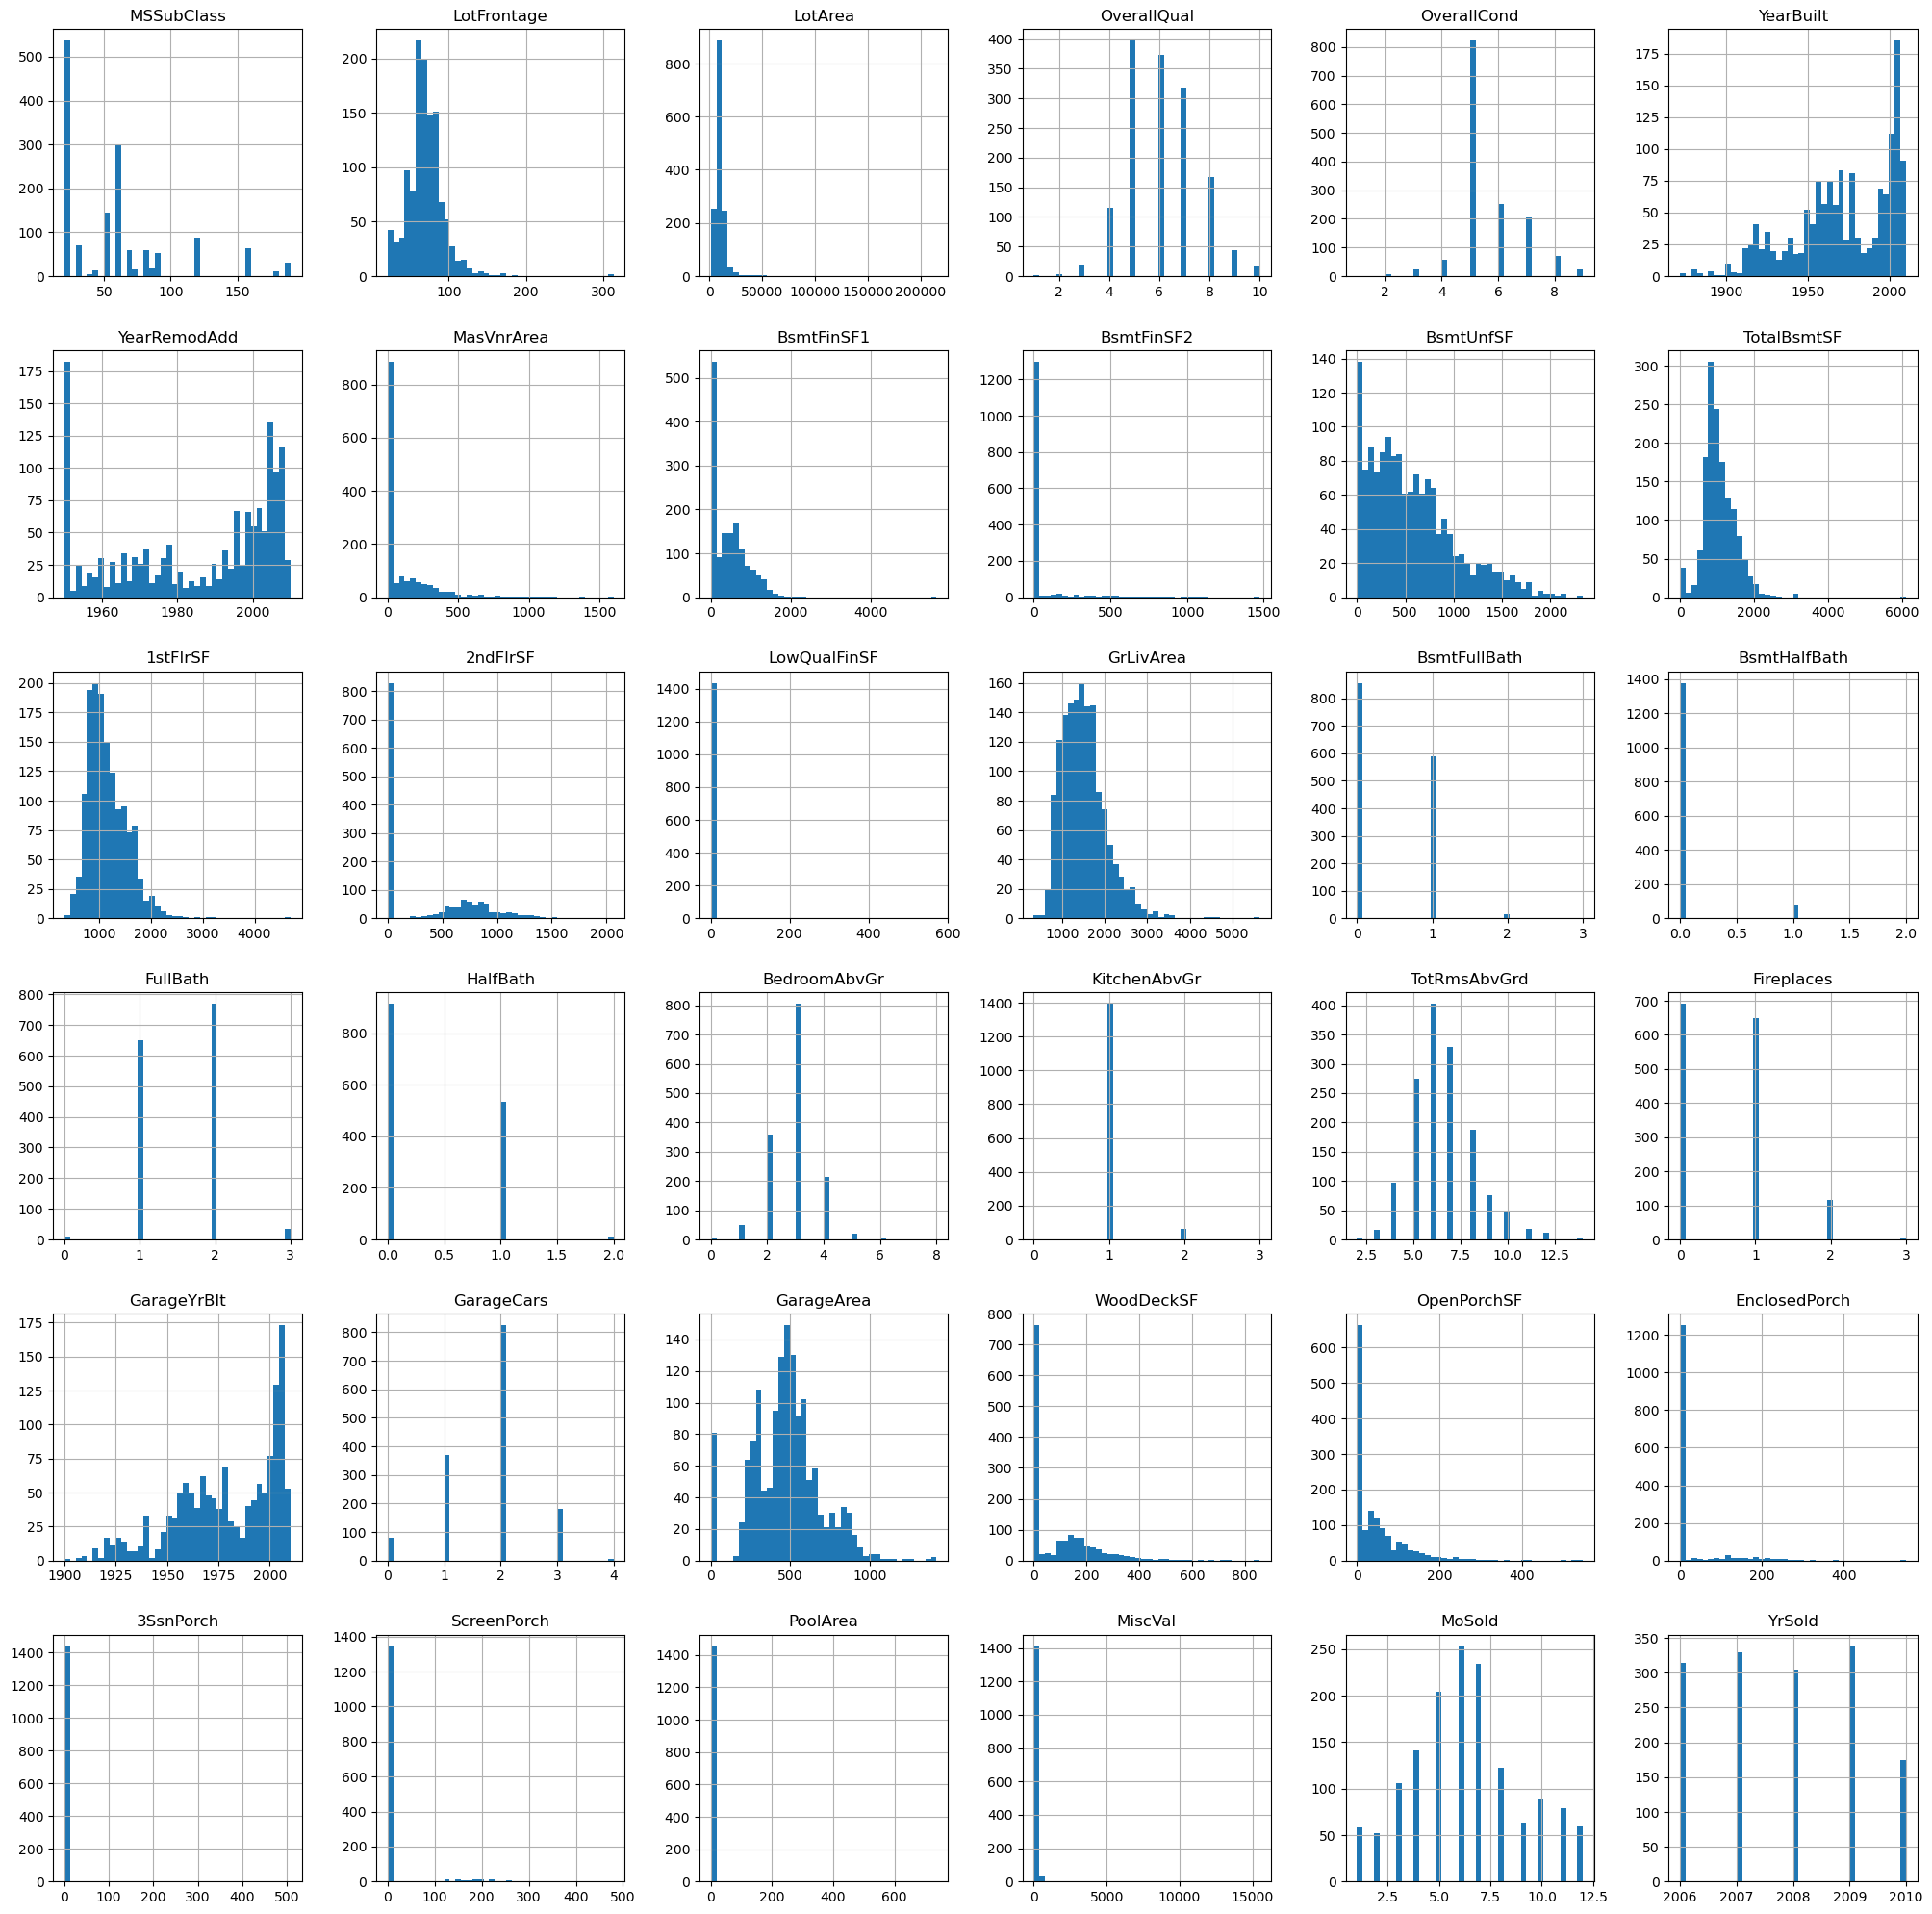

In [18]:
df[num_cols].hist(figsize=(25,25),bins=40)
plt.show()

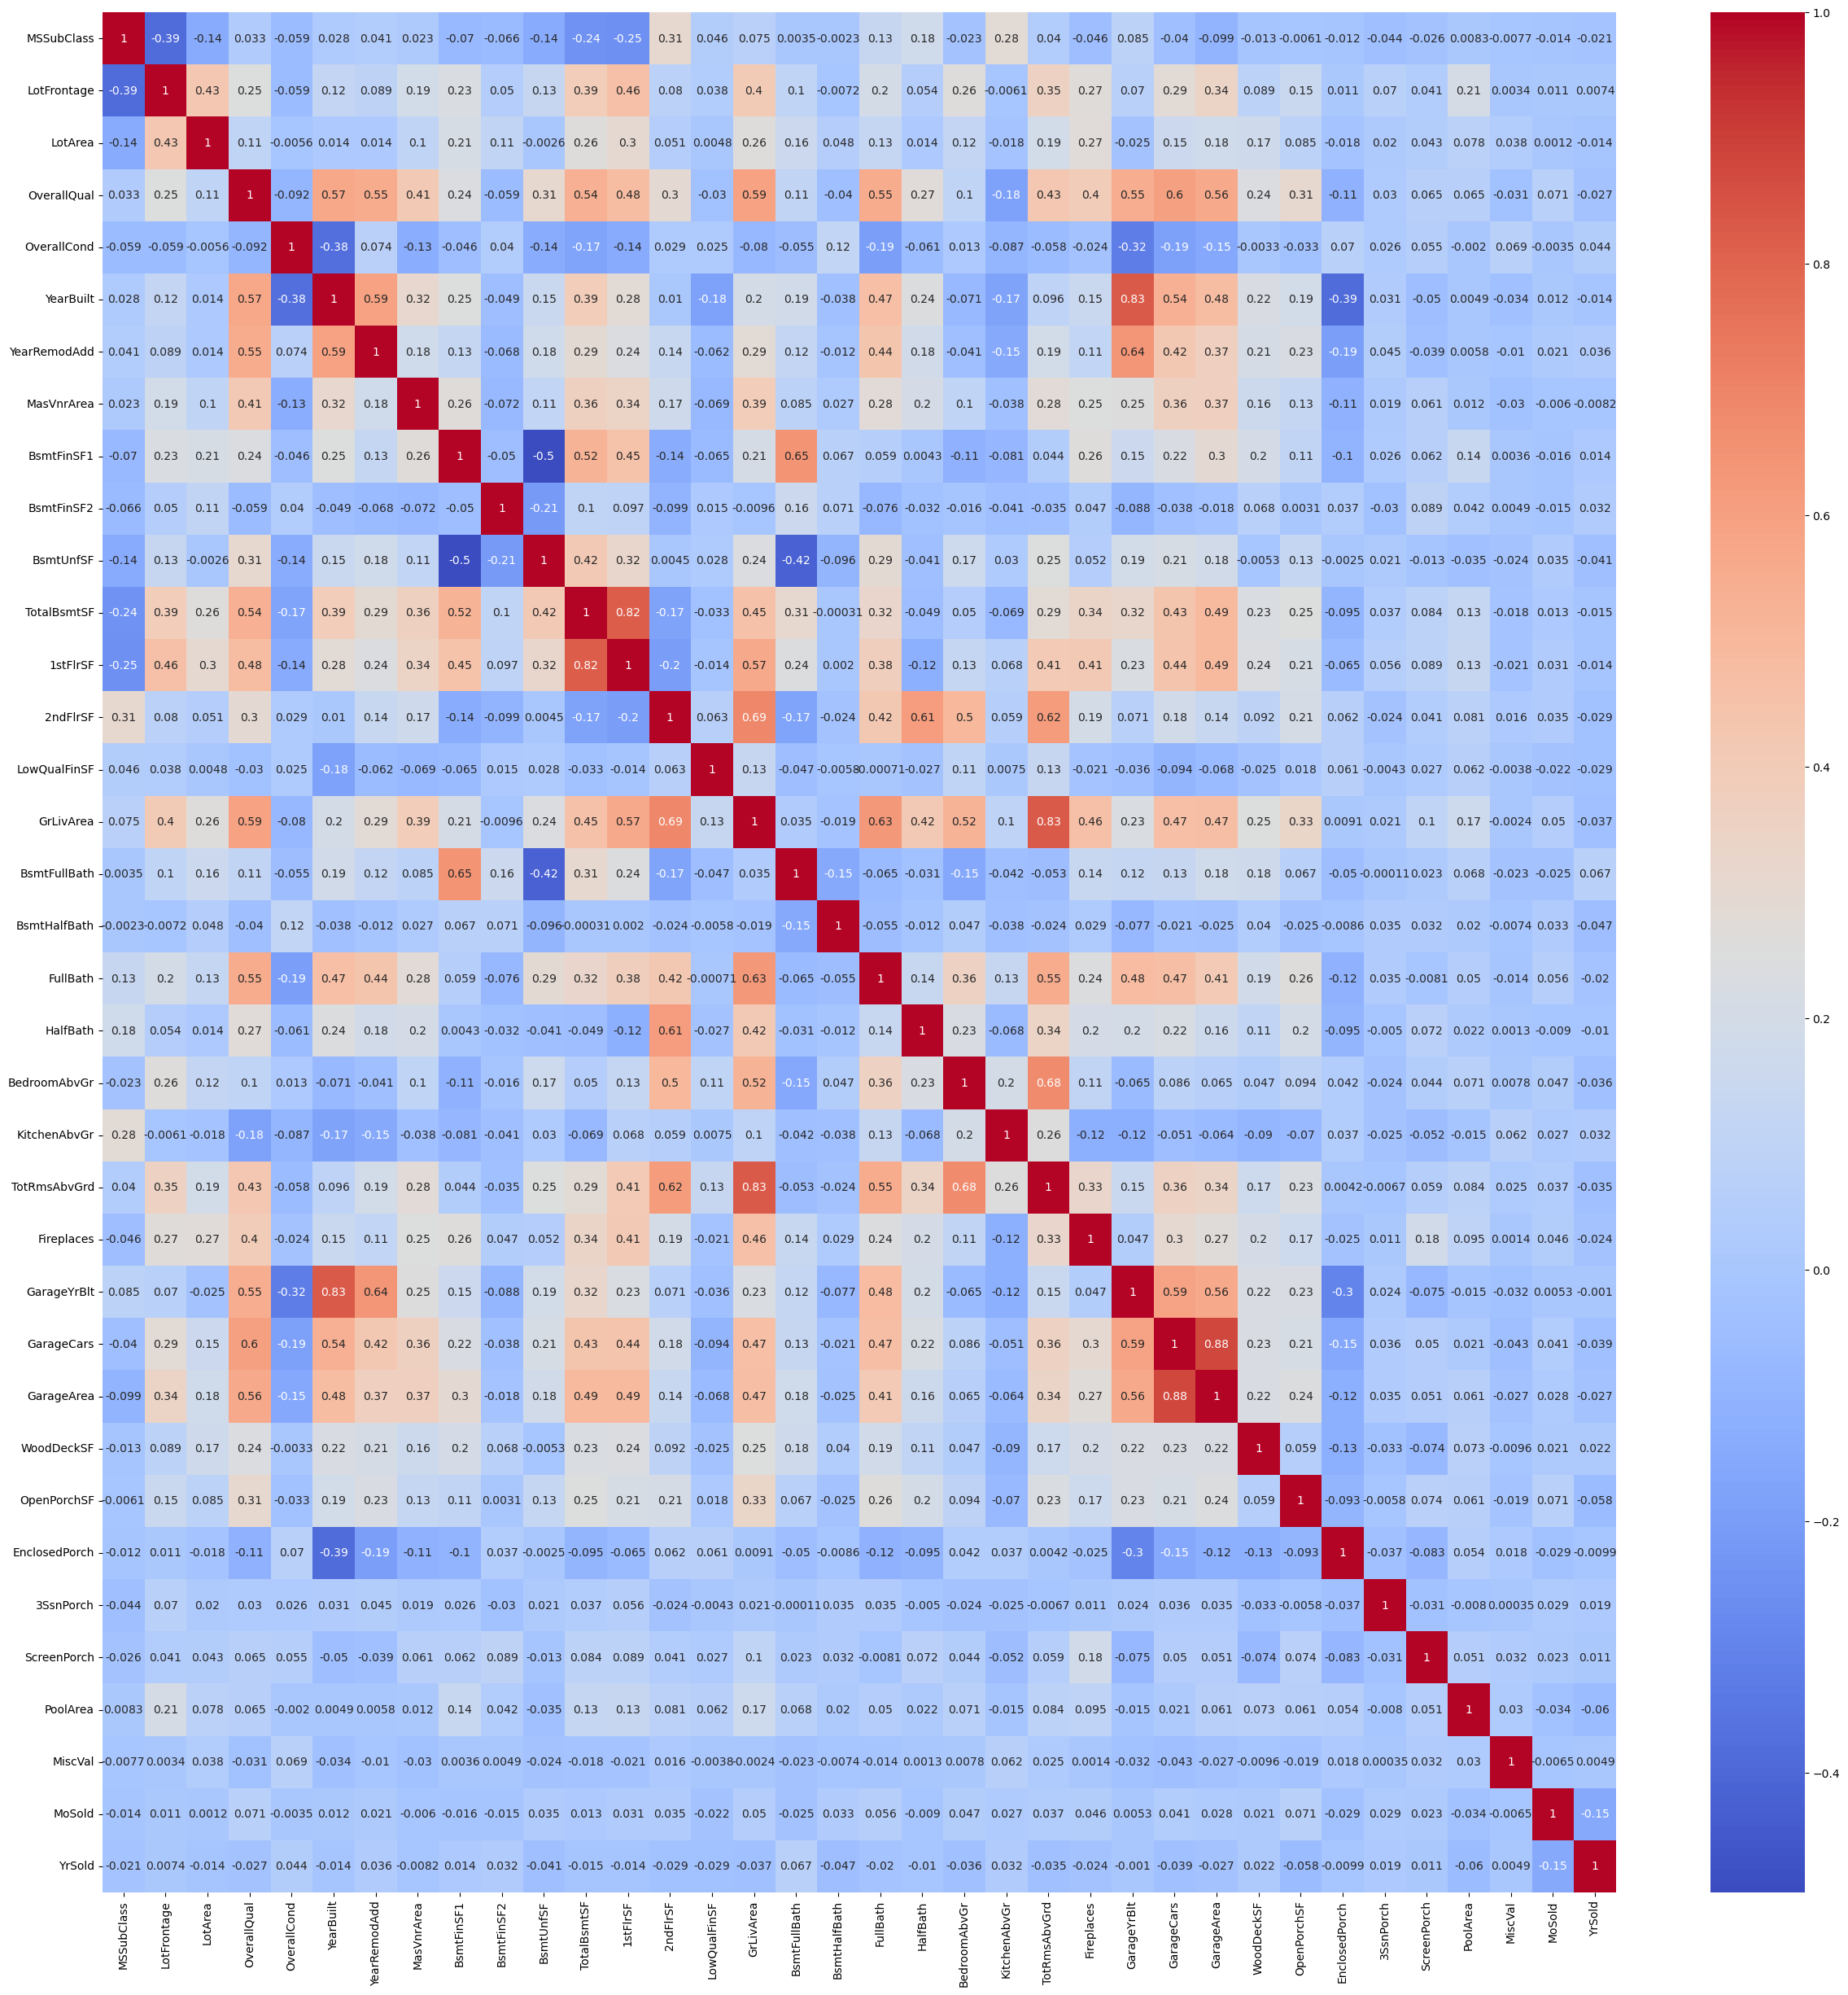

In [19]:
plt.figure(figsize=(30,30))
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm')
plt.show()


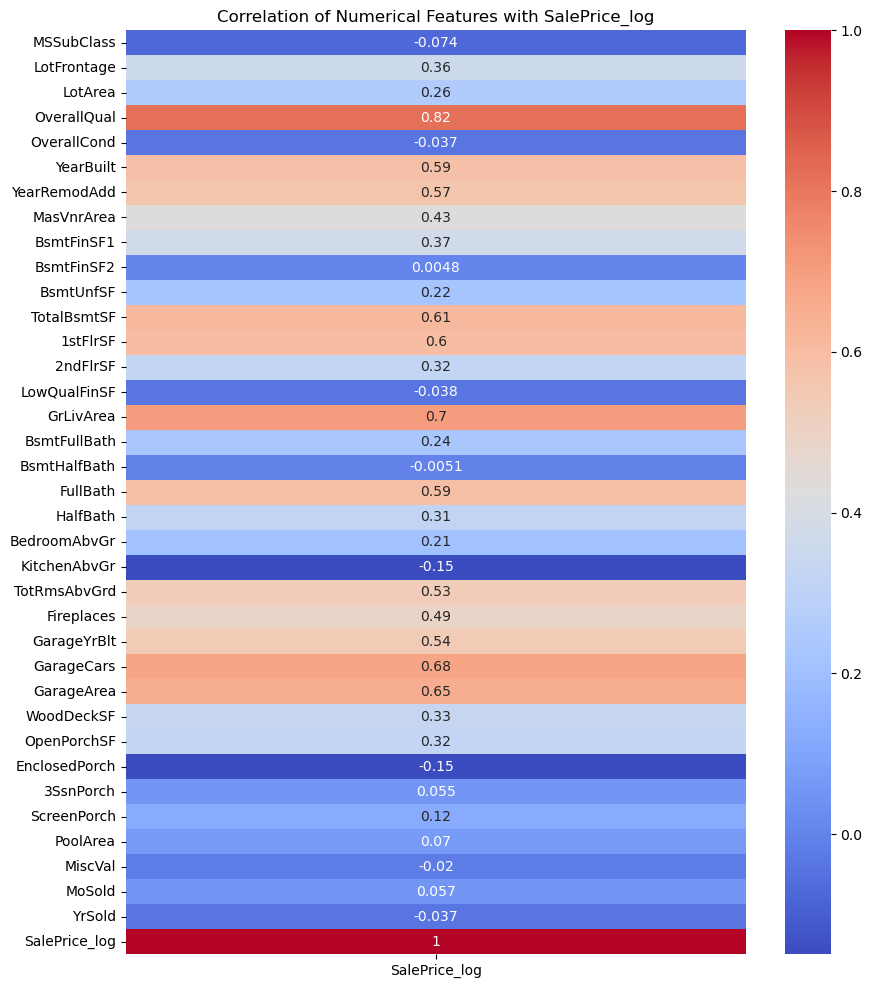

In [20]:
plt.figure(figsize=(10, 12))
sns.heatmap(
    df[num_cols].assign(SalePrice_log=df['SalePrice_log']).corr()[['SalePrice_log']],
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation of Numerical Features with SalePrice_log")
plt.show()


In [21]:
corr = df[num_cols].corrwith(df['SalePrice_log']).sort_values(ascending=False)
corr


OverallQual      0.817185
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
GarageYrBlt      0.541073
TotRmsAbvGrd     0.534422
Fireplaces       0.489450
MasVnrArea       0.430809
BsmtFinSF1       0.372023
LotFrontage      0.355879
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209043
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057330
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorch   -0.149050
dtype: float64

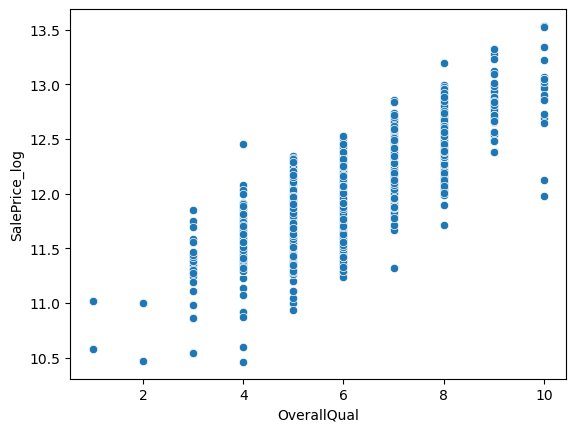

In [22]:
sns.scatterplot(x=df['OverallQual'], y=df['SalePrice_log'])
plt.show()

# OverallQuality exhibits a strong positive and approximately linear relationship with SalePrice_log.


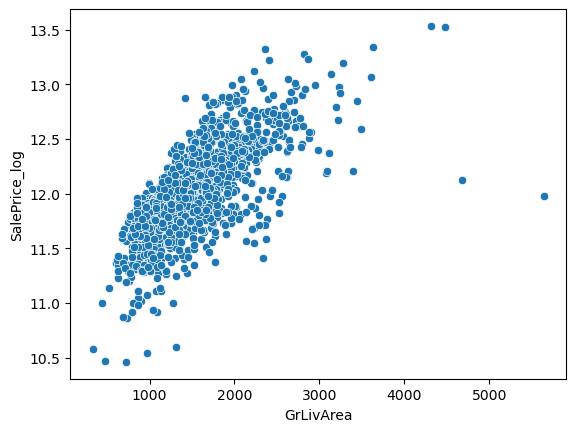

In [23]:
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice_log'])
plt.show()

# GroundLivingArea exhibits a strong positive and approximately linear relationship with SalePrice_log.

# CATEGORICAL Cols EDA

In [24]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [25]:
# Do different categories change the house price or not?

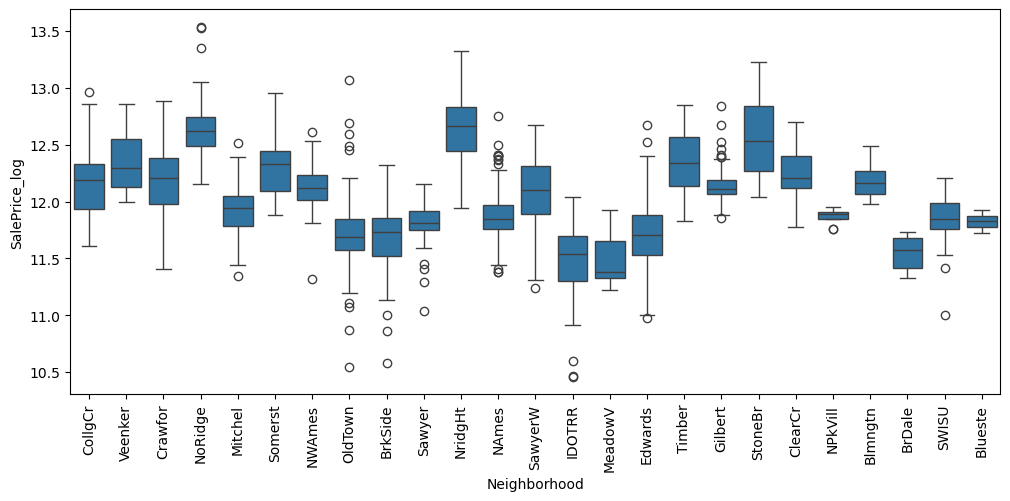

In [26]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df['Neighborhood'], y=df['SalePrice_log'])
plt.xticks(rotation=90)
plt.show()


In [27]:
df.groupby('Neighborhood')['SalePrice_log'].median().sort_values(ascending=False)


Neighborhood
NridgHt    12.660331
NoRidge    12.616529
StoneBr    12.535380
Timber     12.339184
Somerst    12.326077
Veenker    12.292255
Crawfor    12.209193
ClearCr    12.207326
CollgCr    12.191972
Blmngtn    12.160034
NWAmes     12.116700
Gilbert    12.106258
SawyerW    12.100162
Mitchel    11.941462
NPkVill    11.891369
NAmes      11.849405
SWISU      11.845827
Blueste    11.826543
Sawyer     11.813037
BrkSide    11.730225
Edwards    11.709630
OldTown    11.686887
BrDale     11.571204
IDOTRR     11.542494
MeadowV    11.385103
Name: SalePrice_log, dtype: float64

In [28]:
df.groupby('Neighborhood')['SalePrice_log'].agg(['median', 'count']).sort_values('median', ascending=False)


,median,count
Neighborhood,,
NridgHt,12.660331,77
NoRidge,12.616529,41
StoneBr,12.535380,25
Timber,12.339184,38
Somerst,12.326077,86
Veenker,12.292255,11
Crawfor,12.209193,51
ClearCr,12.207326,28
CollgCr,12.191972,150


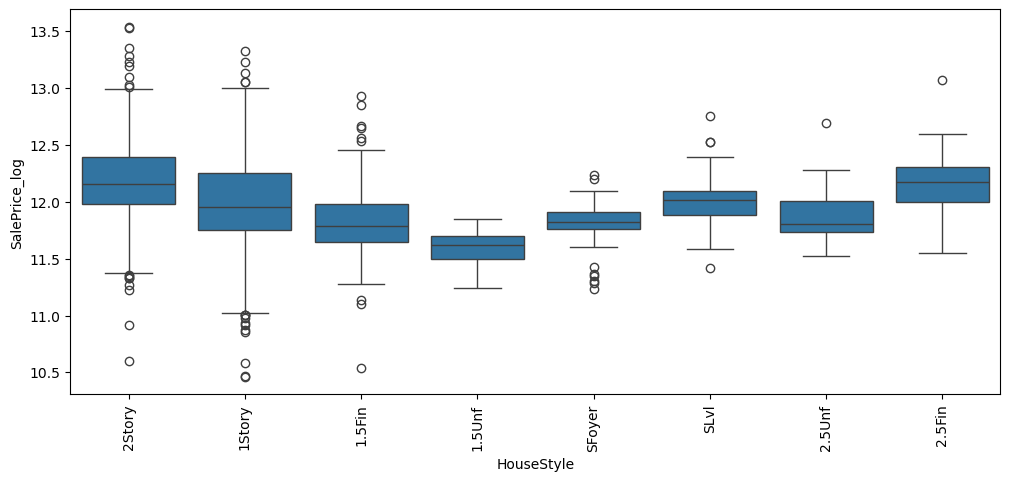

In [29]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df['HouseStyle'], y=df['SalePrice_log'])
plt.xticks(rotation=90)
plt.show()

In [30]:
df.groupby('HouseStyle')['SalePrice_log'].median().sort_values(ascending=False)

HouseStyle
2.5Fin    12.175499
2Story    12.154785
SLvl      12.010672
1Story    11.949571
SFoyer    11.820123
2.5Unf    11.804856
1.5Fin    11.790558
1.5Unf    11.619420
Name: SalePrice_log, dtype: float64

In [31]:
df.groupby('HouseStyle')['SalePrice_log'].agg(['median', 'count']).sort_values('median', ascending=False)

,median,count
HouseStyle,,
2.5Fin,12.175499,8
2Story,12.154785,445
SLvl,12.010672,65
1Story,11.949571,726
SFoyer,11.820123,37
2.5Unf,11.804856,11
1.5Fin,11.790558,154
1.5Unf,11.619420,14


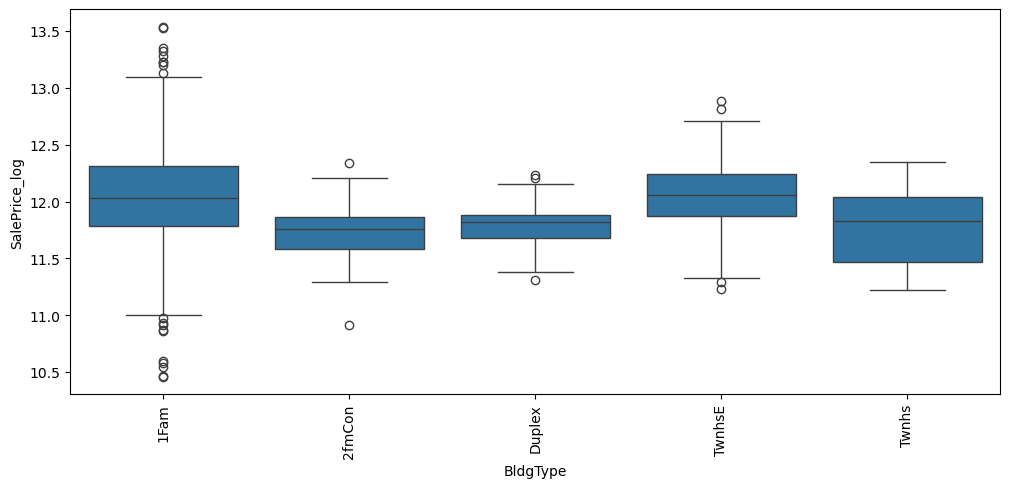

In [32]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df['BldgType'], y=df['SalePrice_log'])
plt.xticks(rotation=90)
plt.show()

In [33]:
df.groupby('BldgType')['SalePrice_log'].median().sort_values(ascending=False)

BldgType
TwnhsE    12.056416
1Fam      12.031130
Twnhs     11.831386
Duplex    11.820270
2fmCon    11.755879
Name: SalePrice_log, dtype: float64

In [34]:
df.groupby('BldgType')['SalePrice_log'].agg(['median', 'count']).sort_values('median', ascending=False)

,median,count
BldgType,,
TwnhsE,12.056416,114
1Fam,12.031130,1220
Twnhs,11.831386,43
Duplex,11.820270,52
2fmCon,11.755879,31


### Categorical EDA shows that features like Neighborhood and HouseStyle and BldgType have significant influence on house prices.

# Handling missing values

In [35]:
df.isnull().sum().to_frame('Missing_Values') \
.assign(DataType=df.dtypes) \
.sort_values(by='Missing_Values', ascending=False)\
.head(20)

,Missing_Values,DataType
PoolQC,1453,object
MiscFeature,1406,object
Alley,1369,object
Fence,1179,object
MasVnrType,872,object
FireplaceQu,690,object
LotFrontage,259,float64
GarageYrBlt,81,float64
GarageType,81,object
GarageFinish,81,object


In [36]:
cat_like_numeric = ['MSSubClass', 'MoSold', 'YrSold']

for col in cat_like_numeric:
    if col in df.columns:
        df[col] = df[col].astype('object')


In [37]:
missval_cat_cols= [
    'PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
    'GarageType','GarageFinish','GarageQual','GarageCond',
    'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','MasVnrType','Electrical'
]

for c in missval_cat_cols:
    if c in df.columns:
        df[c] = df[c].fillna('None')


if 'MasVnrArea' in df.columns:
    df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

In [38]:
# Lotfrontage col depends on neighborhhod.
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'] \
                      .transform(lambda x: x.fillna(x.median()))


In [39]:
if 'GarageYrBlt' in df.columns:      
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

In [40]:
# Numeric Cols - filling NaNs with median
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
for c in num_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())

# Cat Cols - filling NaNs with 'None'
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for c in cat_cols:
    if df[c].isnull().any():
         df[c] = df[c].fillna('None')

In [41]:
df.isnull().sum().sort_values(ascending=False)

MSSubClass       0
Electrical       0
GarageFinish     0
GarageYrBlt      0
GarageType       0
FireplaceQu      0
Fireplaces       0
Functional       0
TotRmsAbvGrd     0
KitchenQual      0
KitchenAbvGr     0
BedroomAbvGr     0
HalfBath         0
FullBath         0
BsmtHalfBath     0
BsmtFullBath     0
GrLivArea        0
LowQualFinSF     0
2ndFlrSF         0
GarageCars       0
GarageArea       0
GarageQual       0
Fence            0
SalePrice        0
SaleCondition    0
SaleType         0
YrSold           0
MoSold           0
MiscVal          0
MiscFeature      0
PoolQC           0
GarageCond       0
PoolArea         0
ScreenPorch      0
3SsnPorch        0
EnclosedPorch    0
OpenPorchSF      0
WoodDeckSF       0
PavedDrive       0
1stFlrSF         0
CentralAir       0
MSZoning         0
HeatingQC        0
YearBuilt        0
OverallCond      0
OverallQual      0
HouseStyle       0
BldgType         0
Condition2       0
Condition1       0
Neighborhood     0
LandSlope        0
LotConfig   

# Outliers handling

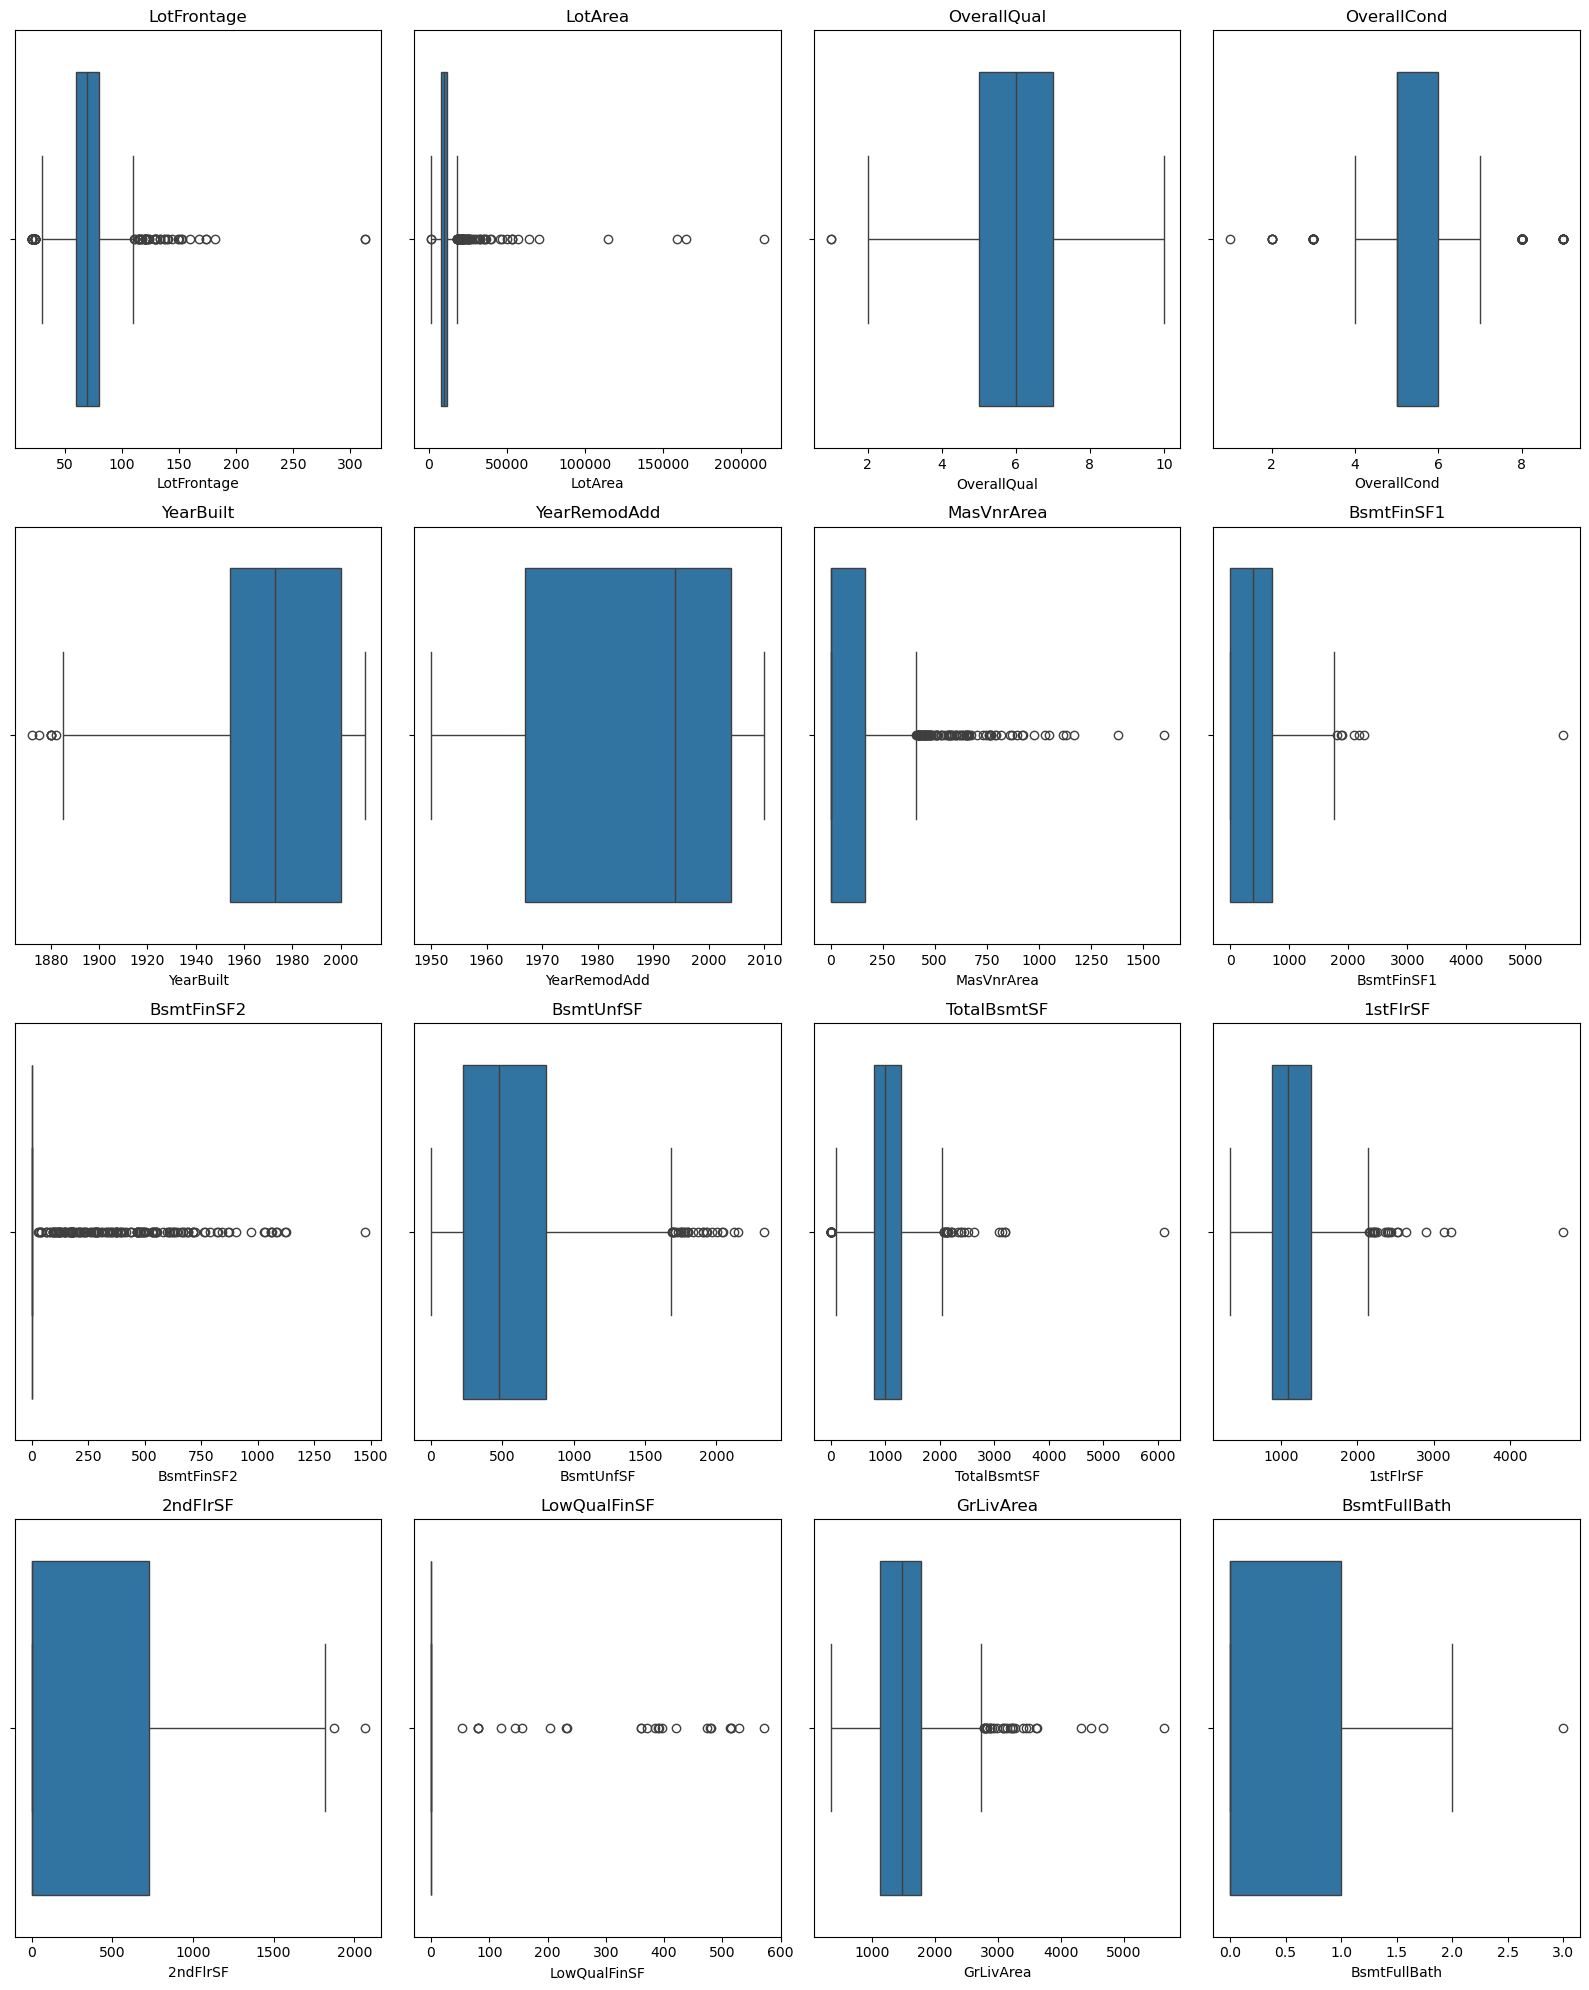

In [42]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(16, 20))
for i, col in enumerate(num_cols[:16]):
    plt.subplot(4, 4, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()
# Box plotting Feature to visually examine the outliers

In [43]:
outlier_count = {}

for col in num_cols:
    q1 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    outlier_count[col] = ((df[col] < q1) | (df[col] > q99)).sum()

pd.DataFrame.from_dict(outlier_count, orient='index', columns=['outlier_count']) \
  .sort_values('outlier_count', ascending=False)

# here we can see the outlier counts

,outlier_count
SalePrice_log,30
SalePrice,30
GrLivArea,30
1stFlrSF,27
LotArea,22
YearBuilt,16
2ndFlrSF,15
ScreenPorch,15
EnclosedPorch,15
OpenPorchSF,15


In [44]:
conti_feat_cols = [
    'LotFrontage','LotArea','MasVnrArea','TotalBsmtSF',
    '1stFlrSF','2ndFlrSF','GrLivArea','GarageArea'
]



In [45]:
outlier_count = {}

for col in conti_feat_cols:
    q1 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    outlier_count[col] = ((df[col] < q1) | (df[col] > q99)).sum()

pd.DataFrame.from_dict(outlier_count, orient='index', columns=['outlier_count']) \
  .sort_values('outlier_count', ascending=False)

,outlier_count
GrLivArea,30
1stFlrSF,27
LotArea,22
LotFrontage,15
MasVnrArea,15
TotalBsmtSF,15
2ndFlrSF,15
GarageArea,15


<Axes: ylabel='GrLivArea'>

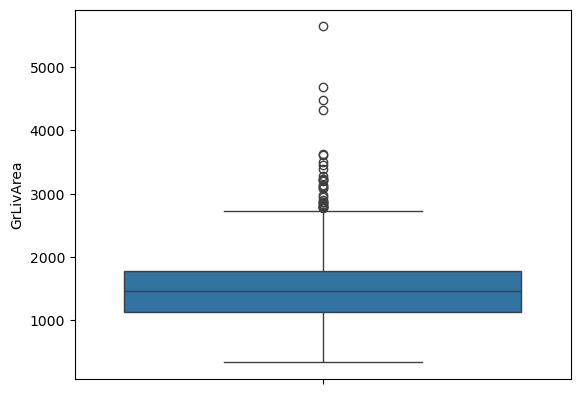

In [46]:
# As GrLivArea is the top just close examining it

sns.boxplot(df['GrLivArea'])

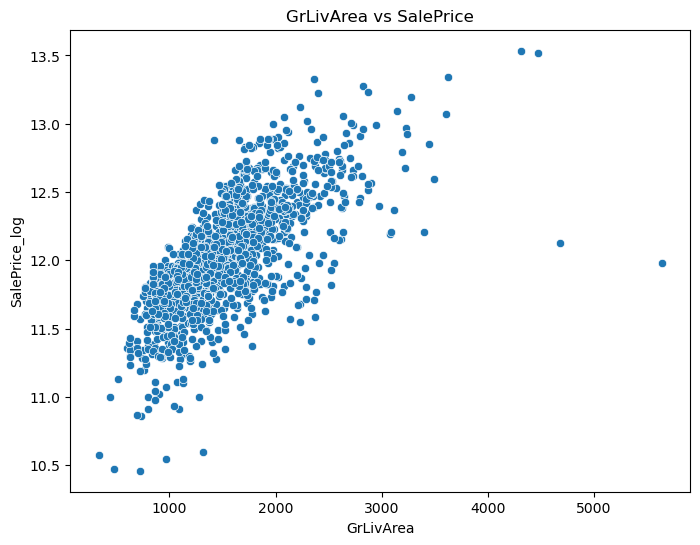

In [47]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='GrLivArea', y='SalePrice_log', data=df)
plt.title('GrLivArea vs SalePrice')
plt.show()


In [48]:
large_houses = df[df['GrLivArea'] > 4000][['GrLivArea', 'SalePrice_log']]
large_houses.sort_values('GrLivArea', ascending=False)


,GrLivArea,SalePrice_log
1298,5642,11.982935
523,4676,12.126764
1182,4476,13.521141
691,4316,13.534474


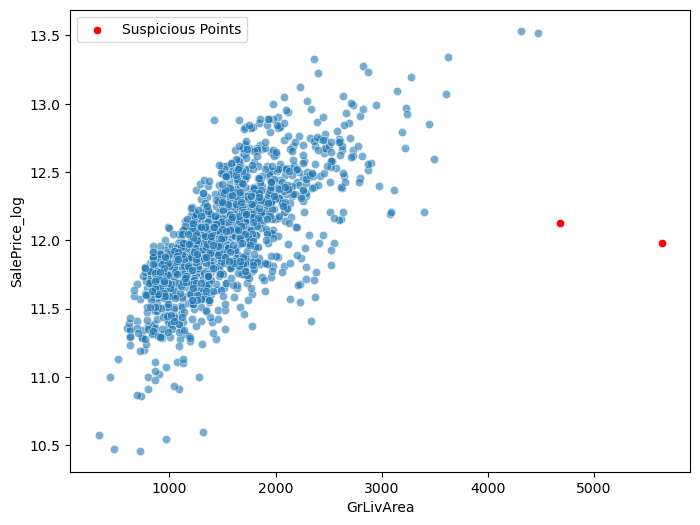

In [49]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='GrLivArea', y='SalePrice_log', data=df, alpha=0.6)

suspicious = df[
    (df['GrLivArea'] > 4500) &
    (df['SalePrice_log'] < df['SalePrice_log'].quantile(0.90))
]

sns.scatterplot(
    x='GrLivArea',
    y='SalePrice_log',
    data=suspicious,
    color='red',
    label='Suspicious Points'
)

plt.legend()
plt.show()


In [50]:
suspicious[['GrLivArea','SalePrice']].sort_values('GrLivArea', ascending=False)


,GrLivArea,SalePrice
1298,5642,160000
523,4676,184750


In [51]:
df = df.drop(suspicious.index)
# # only removing the  above 4500 as it breaks the pattern 

In [52]:
# checking continuous feature skewness
skew_cols = [
    'LotFrontage','LotArea','MasVnrArea','BsmtFinSF1',
    'BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
    '1stFlrSF','2ndFlrSF','GrLivArea','GarageArea'
]

skew_values = df[skew_cols].skew().sort_values(ascending=False)
skew_values


LotArea        12.573925
BsmtFinSF2      4.251925
MasVnrArea      2.696329
LotFrontage     1.547767
GrLivArea       1.010992
BsmtUnfSF       0.920903
1stFlrSF        0.887637
2ndFlrSF        0.812957
BsmtFinSF1      0.764789
TotalBsmtSF     0.511703
GarageArea      0.131748
dtype: float64

In [53]:
# which features has skewness above 0.75 , so that is highly skew.
log_col = skew_values[skew_values > 0.75].index.tolist()
log_col


['LotArea',
 'BsmtFinSF2',
 'MasVnrArea',
 'LotFrontage',
 'GrLivArea',
 'BsmtUnfSF',
 '1stFlrSF',
 '2ndFlrSF',
 'BsmtFinSF1']

In [54]:
# Tranfomring the skewed continues features
for col in log_col:
    df[col] = np.log1p(df[col])


In [55]:
log_cols = df[log_col].skew().sort_values(ascending=False)
log_cols

BsmtFinSF2     2.521222
MasVnrArea     0.506312
2ndFlrSF       0.292784
1stFlrSF       0.006984
GrLivArea     -0.071012
LotArea       -0.181278
BsmtFinSF1    -0.618096
LotFrontage   -1.000319
BsmtUnfSF     -2.184367
dtype: float64

# feature engineering

In [56]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

df['TotalBath'] = (
    df['FullBath'] +
    0.5 * df['HalfBath'] +
    df['BsmtFullBath'] +
    0.5 * df['BsmtHalfBath']
)

df['HouseAge'] = df['YrSold'] - df['YearBuilt']

df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']

# Encoding

In [57]:
# checking differnt levels from  some ordinal colmns. then use map function on it.
df['ExterQual'].unique()

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

In [58]:
df['BsmtQual'].unique()

array(['Gd', 'TA', 'Ex', 'None', 'Fa'], dtype=object)

In [59]:
df['FireplaceQu'].unique()

array(['None', 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [60]:
df['GarageCond'].unique()

array(['TA', 'Fa', 'None', 'Gd', 'Po', 'Ex'], dtype=object)

In [61]:
df['PoolQC'].unique()

array(['None', 'Ex', 'Fa', 'Gd'], dtype=object)

### Encoding on Ordinal categorical columns by Map Function.

In [62]:
# now using map function
qual_map = {
    'None': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}


In [63]:
ordinal_qual_cols = [
    'ExterQual','ExterCond','BsmtQual','BsmtCond',
    'HeatingQC','KitchenQual','FireplaceQu',
    'GarageQual','GarageCond','PoolQC'
]

for col in ordinal_qual_cols:
    if col in df.columns:
        df[col] = df[col].map(qual_map)


In [64]:
Bsmtexpo_map = {'None':0, 'No':1, 'Mn':2, 'Av':3, 'Gd':4}
df['BsmtExposure'] = df['BsmtExposure'].map(Bsmtexpo_map)


In [65]:
garfin_map = {'None':0, 'Unf':1, 'RFn':2, 'Fin':3}
df['GarageFinish'] = df['GarageFinish'].map(garfin_map)


In [66]:
landslope_map = {'Sev':1, 'Mod':2, 'Gtl':3}
df['LandSlope'] = df['LandSlope'].map(landslope_map)


In [67]:
functional_map = {
    'Sal':1, 'Sev':2, 'Maj2':3, 'Maj1':4,
    'Mod':5, 'Min2':6, 'Min1':7, 'Typ':8
}
df['Functional'] = df['Functional'].map(functional_map)


### Binary Encoding

In [68]:
# 0/1 Binary encoding
df['Street'] = df['Street'].map({'Grvl':0, 'Pave':1})
df['CentralAir'] = df['CentralAir'].map({'N':0, 'Y':1})
df['PavedDrive'] = df['PavedDrive'].map({'N':0, 'P':1, 'Y':2})


### Encoding on Nominal categorical columns by One Hot Encoding.

In [69]:
remaining_cat_cols = df.select_dtypes(include=['object']).columns


In [70]:
remaining_cat_cols

Index(['MSSubClass', 'MSZoning', 'Alley', 'LotShape', 'LandContour',
       'Utilities', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtFinType1',
       'BsmtFinType2', 'Heating', 'Electrical', 'GarageType', 'Fence',
       'MiscFeature', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition',
       'HouseAge', 'RemodelAge'],
      dtype='object')

In [71]:
df = pd.get_dummies(df, columns=remaining_cat_cols, drop_first=True)

In [72]:
# one last check on null values.
df.isnull().sum().sum()

np.int64(0)

In [73]:
# checking shape after encoding.
df.shape

(1458, 428)

In [74]:
#  checking how many columns are created after applying One Hot Encoding.
pd.set_option('display.max_columns',None)
df.head()

,LotFrontage,LotArea,Street,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,SalePrice,SalePrice_log,TotalSF,TotalBath,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_120,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Alley_None,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_None,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_None,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_None,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,MoSold_10,MoSold_11,MoSold_12,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,HouseAge_1,HouseAge_2,HouseAge_3,HouseAge_4,HouseAge_5,HouseAge_6,HouseAge_7,HouseAge_8,HouseAge_9,HouseAge_10,HouseAge_11,HouseAge_12,HouseAge_13,HouseAge_14,HouseAge_15,HouseAge_16,HouseAge_17,HouseAge_18,HouseAge_19,HouseAge

# Feature Selection

In [75]:
X = df.drop(['SalePrice', 'SalePrice_log'], axis=1)
y = df['SalePrice_log']


# Task 2:- Create a robust machine learning algorithm to accurately predict the price of the house given the various factors across the market.      

# Modeling

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)


In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [78]:
from sklearn.linear_model import LinearRegression, Ridge , Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score


## Linear Regression

In [79]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train = lr.predict(X_train_scaled)
y_pred_test = lr.predict(X_test_scaled)

print("Linear Regression Results")
print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))

# RMSE (original scale)
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_test)))
print("Test RMSE (Original Scale):", rmse)

cv = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring="r2")
print("CV R2 Mean:", cv.mean())
print("-"*50)


Linear Regression Results
Train R2: 0.9613411593500487
Test R2: 0.8762060562554448
Test RMSE (Original Scale): 24557.951350370233
CV R2 Mean: 0.8502047185327524
--------------------------------------------------


## Ridge Regression

In [80]:
ridge = Ridge(alpha=10)
ridge.fit(X_train_scaled, y_train)

y_pred_train = ridge.predict(X_train_scaled)
y_pred_test = ridge.predict(X_test_scaled)

print("Ridge Regression Results")
print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))

rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_test)))
print("Test RMSE (Original Scale):", rmse)

cv = cross_val_score(ridge, X_train_scaled, y_train, cv=5, scoring="r2")
print("CV R2 Mean:", cv.mean())
print("-"*50)


Ridge Regression Results
Train R2: 0.9599457216844566
Test R2: 0.8862808172199652
Test RMSE (Original Scale): 23459.88090377046
CV R2 Mean: 0.8697671270022631
--------------------------------------------------


## Lasso Regression

In [81]:

lasso = Lasso(alpha=0.001, max_iter=10000)

# Train on scaled data
lasso.fit(X_train_scaled, y_train)

# Predictions
y_pred_train = lasso.predict(X_train_scaled)
y_pred_test = lasso.predict(X_test_scaled)

print("Lasso Regression Results")
print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))

# RMSE (original scale)
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_test)))
print("Test RMSE (Original Scale):", rmse)

# Cross Validation
cv = cross_val_score(lasso, X_train_scaled, y_train, cv=5, scoring="r2")
print("CV R2 Mean:", cv.mean())
print("-"*50)


Lasso Regression Results
Train R2: 0.9538902794581193
Test R2: 0.9049104322574991
Test RMSE (Original Scale): 20899.384036914682
CV R2 Mean: 0.9005679614568038
--------------------------------------------------


## Random Forest

In [82]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

print("Random Forest Results")
print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))

rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_test)))
print("Test RMSE (Original Scale):", rmse)

cv = cross_val_score(rf, X_train, y_train, cv=5, scoring="r2")
print("CV R2 Mean:", cv.mean())
print("-"*50)


Random Forest Results
Train R2: 0.9835438090996411
Test R2: 0.8763702490169997
Test RMSE (Original Scale): 23782.713769078106
CV R2 Mean: 0.8738518717177062
--------------------------------------------------


## XGBOOST

In [83]:
xgb = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.6,
    gamma=0.2,
    reg_alpha=1,
    reg_lambda=2,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_train = xgb.predict(X_train)
y_pred_test = xgb.predict(X_test)

print("XGBoost Results")
print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))

rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_test)))
print("Test RMSE (Original Scale):", rmse)

cv = cross_val_score(xgb, X_train, y_train, cv=5, scoring="r2")
print("CV R2 Mean:", cv.mean())
print("-"*50)


XGBoost Results
Train R2: 0.9228537481407961
Test R2: 0.8884450642323397
Test RMSE (Original Scale): 22449.79175187666
CV R2 Mean: 0.8775084035587645
--------------------------------------------------


## Random Forest Tuning

In [84]:

from sklearn.model_selection import RandomizedSearchCV


#  Model (More Controlled)
rf = RandomForestRegressor(
    random_state=42,
    oob_score=True,
    bootstrap=True
)

# Controlled Parameter Distribution
rf_param = {
    'n_estimators': [300, 400, 500],      # Avoid very high trees
    'max_depth': [8, 10, 15],             # Remove None (no unlimited depth)
    'min_samples_split': [5, 10, 15],     # Increase splitting condition
    'min_samples_leaf': [2, 4, 6],        # Force larger leaf size
    'max_features': ['sqrt', 0.6, 0.7]    # Limit feature usage
}

# Random Search
rf_search = RandomizedSearchCV(
    rf,
    rf_param,
    n_iter=25,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

# Predictions
train_pred_rf = best_rf.predict(X_train)
test_pred_rf = best_rf.predict(X_test)

# Evaluation
train_r2 = r2_score(y_train, train_pred_rf)
test_r2 = r2_score(y_test, test_pred_rf)
gap = train_r2 - test_r2

rmse_rf = np.sqrt(
    mean_squared_error(
        np.expm1(y_test),
        np.expm1(test_pred_rf)
    )
)

cv_score = rf_search.best_score_

print("===== RANDOM FOREST RESULTS (REGULARIZED) =====")
print("Best Parameters:", rf_search.best_params_)
print("-----------------------------------------------")
print(f"Train R2 : {train_r2:.4f}")
print(f"Test R2  : {test_r2:.4f}")
print(f"R2 Gap   : {gap:.4f}")
print("-----------------------------------------------")
print(f"Cross-Validation R2 : {cv_score:.4f}")
print(f"OOB Score           : {best_rf.oob_score_:.4f}")
print(f"Test RMSE (Original Scale): {rmse_rf:.4f}")


===== RANDOM FOREST RESULTS (REGULARIZED) =====
Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.6, 'max_depth': 10}
-----------------------------------------------
Train R2 : 0.9699
Test R2  : 0.8829
R2 Gap   : 0.0870
-----------------------------------------------
Cross-Validation R2 : 0.8812
OOB Score           : 0.8841
Test RMSE (Original Scale): 23174.6880


## XGBoosting Tuning

In [85]:
from sklearn.model_selection import RandomizedSearchCV


#  Model
xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

 # Controlled Parameter Distribution
param_dist = {
    'n_estimators': [300, 400, 500],          # Reduced upper limit
    'learning_rate': [0.03, 0.05],            # Avoid very high LR
    'max_depth': [3, 4, 5],                   # No deep trees
    'min_child_weight': [3, 5, 7],            # Higher = less overfit
    'subsample': [0.6, 0.7, 0.8],             # Force row sampling
    'colsample_bytree': [0.6, 0.7],           # Feature sampling
    'gamma': [0.1, 0.2, 0.3],                 # Force split penalty
    'reg_alpha': [0.5, 1, 2],                 # L1 Regularization
    'reg_lambda': [1, 2, 3]                   # L2 Regularization
}


 # Random Search
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,                
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit
random_search_xgb.fit(X_train, y_train)

best_xgb = random_search_xgb.best_estimator_


# Predictions
train_pred = best_xgb.predict(X_train)
test_pred = best_xgb.predict(X_test)

# Evaluation
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
gap = train_r2 - test_r2

rmse = np.sqrt(
    mean_squared_error(
        np.expm1(y_test),
        np.expm1(test_pred)
    )
)

cv_score = random_search_xgb.best_score_

print("===== XGBOOST RESULTS (REGULARIZED) =====")
print("Best Parameters:", random_search_xgb.best_params_)
print("-------------------------------------------")
print(f"Train R2 : {train_r2:.4f}")
print(f"Test R2  : {test_r2:.4f}")
print(f"R2 Gap   : {gap:.4f}")
print("-------------------------------------------")
print(f"Cross-Validation R2 : {cv_score:.4f}")
print(f"Test RMSE (Original Scale): {rmse:.4f}")



Fitting 5 folds for each of 30 candidates, totalling 150 fits
===== XGBOOST RESULTS (REGULARIZED) =====
Best Parameters: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 400, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.6}
-------------------------------------------
Train R2 : 0.9354
Test R2  : 0.9062
R2 Gap   : 0.0292
-------------------------------------------
Cross-Validation R2 : 0.8949
Test RMSE (Original Scale): 20636.4932


# Executive Summary

### This project focuses on predicting residential house prices in Ames, Iowa using machine learning techniques. The dataset contains 80 explanatory variables describing structural, locational, and quality-related characteristics of houses.

### A complete data analysis was performed, followed by preprocessing, feature engineering, model building, and hyperparameter tuning. Among all tested models, XGBoost achieved the best performance with a Test R² score of 0.908 and RMSE of approximately 19,699.

### The final model is robust, accurate, and suitable for real-world house price estimation.
### ---------------------------------------------------------------------------------------------------------------------------

# Problem Statement

### The objective of this project is:

#### • To analyze housing market data
#### • To build a robust machine learning model to predict house prices
#### • To identify relationships between features and price
#### • To provide actionable suggestions for customers
### -----------------------------------------------------------------------------------------------------------------------------------

# Dataset Description

## The dataset contains 80 explanatory variables describing:

#### • Structural details (area, rooms, basement)
#### • Quality indicators (OverallQual, KitchenQual)
#### • Garage information
#### • Construction year
#### • Neighborhood
#### • Exterior and interior features

# Target Variable:
## SalePrice – Final selling price of the house.

### The dataset includes both numerical and categorical features.
### --------------------------------------------------------------------------------------------------------------------------------

# 1.Complete Data Analysis Report

## 1.1 Data Understanding

### The dataset contains both numerical and categorical features.

### Several features contain missing values.

### The target variable (SalePrice) is positively skewed.
### ------------------------------------------------------------------------------

## 1.2 Data Cleaning

### Missing values were handled using appropriate imputation techniques.

### Irrelevant or redundant features were removed if necessary.

### Outliers were checked and treated to avoid distortion in model performance.
### -------------------------------------------------------------------------------
## 1.3 Target Variable Transformation

### The SalePrice variable was highly skewed.

### To normalize the distribution:

### SalePrice → log1p(SalePrice)

### This improved model stability and reduced the impact of extreme values.
### -------------------------------------------------------------------------------
## 1.4 Exploratory Data Analysis (EDA)

### Key observations from analysis:

### Overall Quality (OverallQual) strongly impacts price.

### Ground Living Area (GrLivArea) shows strong positive correlation with SalePrice.

### Newer houses generally have higher prices.

### Neighborhood significantly influences house prices.

### Larger garage capacity tends to increase price.

### Correlation analysis helped identify important predictors.
### --------------------------------------------------------------------------------

## Correlation Analysis

### Strong Positive Correlations:

### • OverallQual
### • GrLivArea
### • TotalBsmtSF
### • GarageCars
### • YearBuilt

## Insights:

### • Higher quality significantly increases price
### • Larger living area leads to higher price
### • Newer houses are generally more expensive
### • Neighborhood impacts price significantly
###  ---------------------------------------------------------------------------------------

# 1.5Feature Engineering

### • Log transformation applied on skewed features
### • Categorical encoding performed
### • Train-test split applied for unbiased evaluation
### -----------------------------------------------------------------------------------------------

# 2.Robust Machine Learning Model
## Models Implemented

#### • Linear Regression
#### • Ridge Regression
#### • Lasso Regression
#### • Random Forest Regressor
#### • XGBoost Regressor

## Ensemble models were included to capture nonlinear relationships.
### -----------------------------------------------------------------------

# Hyperparameter Tuning

## RandomizedSearchCV with 5-fold cross-validation was used.
    
## Random Forest Tuned Parameters:

#### • n_estimators
#### • max_depth
#### • min_samples_split
#### • min_samples_leaf
#### • max_features

## XGBoost Tuned Parameters:

#### • n_estimators
#### • learning_rate
#### • max_depth
#### • min_child_weight
#### • subsample
#### • colsample_bytree
#### • gamma
#### • reg_alpha
#### • reg_lambda
### --------------------------------------------------------------------------

## Final Model Performance
## Model	Train R²	Test R²	RMSE
#### Random Forest	0.967	0.855	26,298
#### XGBoost	0.993	0.908	19,699

### XGBoost achieved the highest Test R² and lowest RMSE.
### --------------------------------------------------------------------------

# Relationship Between Features and Price
## Key Price Drivers

#### Overall Quality

#### Living Area (GrLivArea)

#### Garage Capacity

#### Basement Area

#### Construction Year

#### Neighborhood

# Observations

#### • Quality impacts price more than number of bedrooms
#### • Location significantly influences value
#### • Larger usable space increases price
#### • Houses with garages and finished basements are valued higher

### Thus, house price varies based on structural quality, usable space, and location.
### ---------------------------------------------------------------------------------------

# 3.Customer Suggestions
## For Budget Buyers

#### • Choose moderate neighborhoods
#### • Prefer older but well-maintained houses
#### • Focus on usable space rather than luxury upgrades

## For Investment Buyers

#### • Invest in high-growth neighborhoods
#### • Target houses with renovation potential
#### • Higher quality rating increases resale value

## For Family Buyers

#### • Prioritize OverallQual and GrLivArea
#### • Consider garage capacity and basement space
#### • Check neighborhood safety and amenities

## Smart Buying Strategy

#### • Do not focus only on bedroom count
#### • Evaluate overall construction quality
#### • Compare price per square foot
#### • Consider long-term resale potential
### ----------------------------------------------------------------------------------------

# Model Justification

## XGBoost was selected because:

#### • Highest predictive accuracy
#### • Better generalization on unseen data
#### • Lower error
#### • Built-in regularization prevents overfitting
### ------------------------------------------------------------------------------------------------

# Challenges Faced During the Project

#### During the development of the house price prediction model, several technical and analytical challenges were encountered:

## Handling Missing Values

#### The dataset contained missing values in multiple numerical and categorical features. Choosing appropriate imputation strategies without introducing bias was a critical step.

## Skewed Target Variable

#### The SalePrice variable was highly positively skewed. This could negatively impact regression performance. Applying log transformation was necessary to stabilize variance and improve model accuracy.

##  High Dimensionality

#### With 80 explanatory variables (and more after encoding), the dataset became high-dimensional. Managing feature space without causing overfitting was challenging.

## Encoding Categorical Variables

#### The dataset contained many categorical features. Proper encoding was required to convert them into numerical format while preserving meaningful relationships.

## Overfitting Risk in Ensemble Models

#### Tree-based ensemble models such as Random Forest and XGBoost showed very high training scores, indicating potential overfitting. Hyperparameter tuning and cross-validation were necessary to ensure good generalization.

## Model Selection and Comparison

#### Multiple models were tested. Selecting the best model required careful comparison using consistent evaluation metrics (R² and RMSE).

## Interpreting Feature Importance

#### Understanding which features truly influence price required careful correlation analysis and feature importance evaluation.
### __________________________________________________________________________________________________________________________________________

## How These Challenges Were Overcome

#### • Proper preprocessing pipeline was created
#### • Log transformation reduced skewness
#### • Cross-validation ensured robust model evaluation
#### • Hyperparameter tuning controlled overfitting
#### • Systematic model comparison identified the best performer

### ---------------------------------------------------------------------------------

# Future Scope

## Although the developed model performs well, further improvements can be explored in the future:

## Advanced Feature Engineering

#### More domain-driven features such as price per square foot, total usable area, and renovation impact can be engineered.

## Feature Selection Techniques

#### Techniques such as Recursive Feature Elimination (RFE) or SHAP analysis can be used to select the most influential features.

## Model Stacking

#### Combining multiple models using stacking or blending techniques may further improve predictive performance.

## Deployment

#### The model can be deployed as a web application to provide real-time house price predictions for users.

## Market Trend Integration

#### Incorporating external factors such as economic indicators, interest rates, and regional development trends may improve long-term prediction accuracy.
### ---------------------------------------------------------------------------------------------------------------

# Final Conclusion

#### This project successfully developed a complete end-to-end machine learning pipeline for house price prediction using the Ames Housing dataset.

#### Through systematic preprocessing, skewness correction, feature encoding, and model tuning, predictive accuracy was significantly improved.

#### Among all models tested, XGBoost delivered the best performance with a Test R² score of 0.908 and RMSE of approximately 19,699, demonstrating strong reliability and robustness.

#### The study confirms that house prices are primarily influenced by overall quality, living area, construction year, garage capacity, and neighborhood.

#### This project demonstrates how structured data analysis combined with advanced ensemble learning techniques can produce accurate and business-relevant predictions for the real estate market.